In [95]:
import numpy as np
import matplotlib.pyplot as plt

In [121]:
start_bet = 10
cut_loss = 1000
chance = 0.7
win_mult = 1.5
n_games = 1000


In [122]:
def bet1(start_bet, cut_loss, chance, win_mult, n_games):
    losses = 0
    wins = 0
    cur_bet = start_bet

    for i in range(n_games):

        draw = np.random.choice([0, 1], p=[1-chance, chance])

        losses += cur_bet

        if draw == 1:
            wins += cur_bet * win_mult - losses
            cur_bet = start_bet
            losses = 0
        
        else:
            cur_bet *= 2

            if losses > cut_loss:
                wins -= losses
                cur_bet = start_bet
                losses = 0

    return wins


In [123]:
def bet2(start_bet, cut_loss, chance, win_mult, n_games):
    losses = 0
    cur_losses = 0
    wins = 0
    cur_bet = start_bet

    chain = []

    for i in range(n_games):

        draw = np.random.choice([0, 1], p=[1-chance, chance])

        losses += cur_bet
        cur_losses += cur_bet

        if draw == 1:
            wins += cur_bet * win_mult
            cur_bet = start_bet
            cur_losses = 0

        
        else:
            cur_bet *= 2

            if cur_losses > cut_loss:
                cur_bet = start_bet
                cur_losses = 0

        cur_net = wins - losses
        chain += [cur_net]

    return cur_net, chain


In [124]:
bet1(start_bet, cut_loss, chance, win_mult, n_games)

1265.0

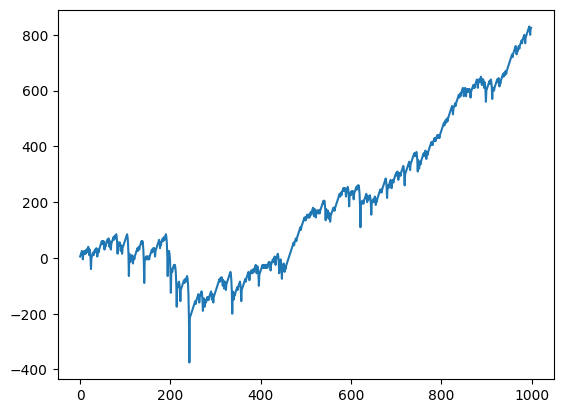

In [128]:
plt.plot( bet2(start_bet, cut_loss, chance, win_mult, n_games)[1] )